In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import constants

In [3]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/"
SAMPLE_ID = "20250828_NEG"
MODALITY_NAME = "MSI"

OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)

In [4]:
lipidomics.preprocess_lipidomics(
    path=PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    peak_picking = True,
    prominence = 0.01,
    window_tolerance = 10,
    dynamic_window = True,
    dynamic_window_factor = 1e6
)

Reading imzML file: /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/20250828_NEG/MSI/20250828_neg_nor_after_srs_washed.imzML, associated with IBD file /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/20250828_NEG/MSI/20250828_neg_nor_after_srs_washed.ibd
Total unique m/z values: 361658. The process will iterate as long as there are overlapping clusters.



Interpolating intensities: 100%|██████████| 121547/121547 [01:01<00:00, 1961.14it/s]


In [5]:
reference_mz = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_reference_mz.npy'))
intensities = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_intensities_matrix.npy'))

In [6]:
print(f"Reference m/z shape: {reference_mz.shape}")
print(f"Intensities shape: {intensities.shape}")

Reference m/z shape: (9021,)
Intensities shape: (546, 483, 9021)


In [7]:
alignment_engine = alignment.Aligner(PATH, SAMPLE_ID)

In [8]:
msi_image = alignment_engine._generate_msi_image(OUTPUT_PATH)

In [9]:
# Flip the image across the y-axis
#msi_image = np.flip(msi_image, axis=1)
# Flip across the x-axis
msi_image = np.flip(msi_image, axis=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


Text(0.5, 1.0, 'MSI Image for 20250828_NEG')

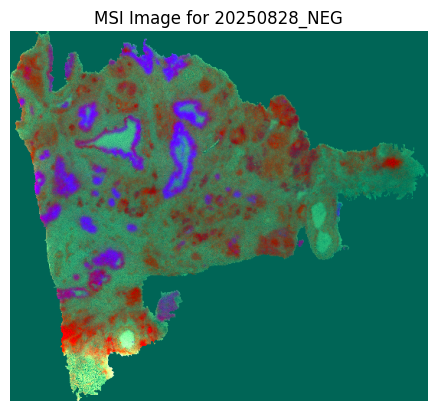

In [10]:
plt.imshow(msi_image, cmap='gray')
plt.axis('off')
plt.title(f"MSI Image for {SAMPLE_ID}")

In [14]:
prova = intensities.reshape(-1, intensities.shape[-1])
print(f"Prova shape: {prova.shape}")

filtered_intensities = prova[prova.sum(axis=1) > 0]
print(f"Filtered intensities shape: {filtered_intensities.shape}")

Prova shape: (3432, 1019)
Filtered intensities shape: (2290, 1019)


In [21]:
# Compute PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_embedding = pca.fit_transform(filtered_intensities)

# Normalize the PCA embedding
pca_embedding = (pca_embedding - np.min(pca_embedding)) / (np.max(pca_embedding) - np.min(pca_embedding))


/mnt/data/lorenzo/miniconda3/envs/sandbox/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Text(0.5, 1.0, 'UMAP Embedding for 00103993-2')

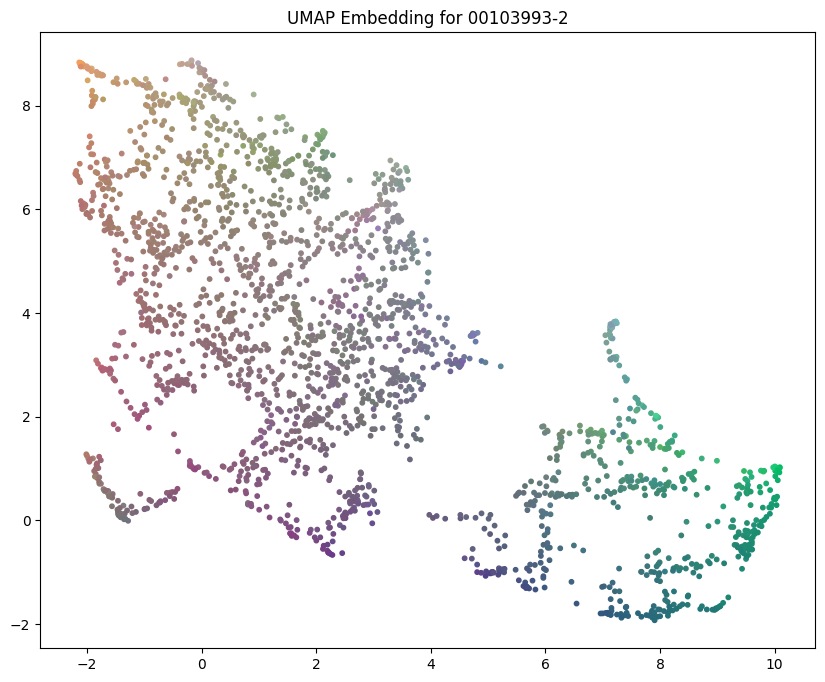

In [22]:
import umap

# Perform UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_embedding = umap_model.fit_transform(filtered_intensities)

# Plot UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=10, c=pca_embedding)
plt.title(f"UMAP Embedding for {SAMPLE_ID}")